# 06b — PyCAP Uncertainty Report Figures

**Purpose:** Create clean, report-ready figures and summary tables from the PyCAP uncertainty workflow.

This notebook pulls together results from:

```text
04_pycap_parameter_perturbation.ipynb
05a_pycap_parameter_perturbation_selected_wells.ipynb
05b_pycap_monte_carlo_uncertainty.ipynb
06a_compare_uncertainty_results_to_pareto_members.ipynb
```

The goal is to turn the analysis outputs into figures that can be used in:

- independent project report
- presentation slides
- advisor/professor meeting notes
- future manuscript-style figures

## What this notebook does

It does **not** rerun PyCAP, MODFLOW, or PEST++.

It only reads previously generated result tables and creates cleaned figures.


## 1. Imports and project-root setup

In [1]:
from pathlib import Path
import os
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start=None):
    """Find the repository root by looking for common project marker files."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "environment.yml").exists():
            return candidate

    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Try opening Jupyter from the Modeling-Uncertainties repo root."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"Python executable: {sys.executable}")


Project root: /workspaces/Modeling-Uncertainties
Current working directory: /workspaces/Modeling-Uncertainties
Python executable: /opt/conda/envs/gw_uncertainty/bin/python


## 2. Define input and output paths

In [2]:
RESULTS_DIR = PROJECT_ROOT / "results"
PYCAP_RESULTS_DIR = RESULTS_DIR / "pycap_runs"

PARAM_TABLES_DIR = PYCAP_RESULTS_DIR / "parameter_perturbation" / "tables"
SELECTED_TABLES_DIR = PYCAP_RESULTS_DIR / "selected_wells_perturbation" / "tables"
MC_TABLES_DIR = PYCAP_RESULTS_DIR / "monte_carlo_uncertainty" / "tables"
PARETO_TABLES_DIR = PYCAP_RESULTS_DIR / "pareto_uncertainty_comparison" / "tables"

REPORT_DIR = PYCAP_RESULTS_DIR / "report_figures"
REPORT_TABLES_DIR = REPORT_DIR / "tables"
REPORT_FIGURES_DIR = REPORT_DIR / "figures"

for folder in [REPORT_DIR, REPORT_TABLES_DIR, REPORT_FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PUBLIC_RIGHTS_FLOW_CFS = 6.8
BASELINE_HOOVER_STREAMFLOW_CFS = 8.6
PRF_ALLOWED_DEPLETION_CFS = BASELINE_HOOVER_STREAMFLOW_CFS - PUBLIC_RIGHTS_FLOW_CFS

print(f"Parameter perturbation tables: {PARAM_TABLES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Selected-well tables:          {SELECTED_TABLES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Monte Carlo tables:            {MC_TABLES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Pareto comparison tables:      {PARETO_TABLES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Report output folder:          {REPORT_DIR.relative_to(PROJECT_ROOT)}")


Parameter perturbation tables: results/pycap_runs/parameter_perturbation/tables
Selected-well tables:          results/pycap_runs/selected_wells_perturbation/tables
Monte Carlo tables:            results/pycap_runs/monte_carlo_uncertainty/tables
Pareto comparison tables:      results/pycap_runs/pareto_uncertainty_comparison/tables
Report output folder:          results/pycap_runs/report_figures


## 3. Helper functions

These functions keep the figure workflow consistent.


In [3]:
figure_manifest = []

def require_file(path, label):
    """Raise a clear error if a required input file is missing."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required file for {label}: {path.relative_to(PROJECT_ROOT)}\n"
            "Run the upstream notebook that creates this file before running 06b."
        )
    return path


def save_figure(fig_name, description):
    """Save the active matplotlib figure and record it in the figure manifest."""
    fig_path = REPORT_FIGURES_DIR / fig_name
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    figure_manifest.append(
        {
            "figure_file": fig_name,
            "relative_path": str(fig_path.relative_to(PROJECT_ROOT)),
            "description": description,
        }
    )
    print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")
    return fig_path


def clean_scenario_label(label):
    """Make scenario names easier to read on figures."""
    replacements = {
        "baseline": "Baseline",
        "T_low_90": "T × 0.90",
        "T_high_110": "T × 1.10",
        "S_low_90": "S × 0.90",
        "S_high_110": "S × 1.10",
        "Q_low_90": "Q × 0.90",
        "Q_high_110": "Q × 1.10",
    }
    return replacements.get(str(label), str(label))


def add_prf_line():
    """Add the Public Rights Flow line to streamflow plots."""
    plt.axhline(PUBLIC_RIGHTS_FLOW_CFS, linestyle="--", label="Public Rights Flow = 6.8 cfs")


def add_dp_threshold_line(threshold=0.20):
    """Add common depletion-potential threshold line."""
    plt.axhline(threshold, linestyle="--", label=f"DP = {threshold:.2f}")


## 4. Load result tables from upstream notebooks

In [4]:
# 04 outputs
scenario_summary_path = require_file(
    PARAM_TABLES_DIR / "scenario_summary.csv",
    "04 scenario summary",
)
change_summary_path = require_file(
    PARAM_TABLES_DIR / "scenario_change_summary.csv",
    "04 change summary",
)
threshold_summary_path = require_file(
    PARAM_TABLES_DIR / "threshold_summary_by_scenario.csv",
    "04 threshold summary",
)
all_dp_path = require_file(
    PARAM_TABLES_DIR / "all_scenarios_depletion_potential.csv",
    "04 all scenario DP table",
)

scenario_summary = pd.read_csv(scenario_summary_path)
change_summary = pd.read_csv(change_summary_path)
threshold_summary = pd.read_csv(threshold_summary_path)
all_dp = pd.read_csv(all_dp_path)

# 05a outputs
selected_comparisons_path = require_file(
    SELECTED_TABLES_DIR / "selected_well_scenario_vs_baseline.csv",
    "05a selected-well comparisons",
)
selected_sensitivity_path = require_file(
    SELECTED_TABLES_DIR / "selected_well_sensitivity_summary.csv",
    "05a selected-well sensitivity summary",
)
selected_threshold_crossings_path = require_file(
    SELECTED_TABLES_DIR / "selected_well_dp_020_threshold_crossings.csv",
    "05a selected-well threshold crossings",
)
selected_wells_path = require_file(
    SELECTED_TABLES_DIR / "selected_wells.csv",
    "05a selected wells",
)

selected_comparisons = pd.read_csv(selected_comparisons_path)
selected_sensitivity = pd.read_csv(selected_sensitivity_path)
selected_threshold_crossings = pd.read_csv(selected_threshold_crossings_path)
selected_wells = pd.read_csv(selected_wells_path)

# 05b outputs
mc_summary_path = require_file(
    MC_TABLES_DIR / "monte_carlo_summary.csv",
    "05b Monte Carlo summary",
)
mc_output_stats_path = require_file(
    MC_TABLES_DIR / "monte_carlo_output_summary_statistics.csv",
    "05b Monte Carlo output statistics",
)
baseline_vs_mc_path = require_file(
    MC_TABLES_DIR / "baseline_vs_monte_carlo_summary.csv",
    "05b baseline vs Monte Carlo",
)
top25_uncertainty_path = require_file(
    MC_TABLES_DIR / "top25_well_uncertainty_summary.csv",
    "05b top-25 well uncertainty",
)

mc_summary = pd.read_csv(mc_summary_path)
mc_output_stats = pd.read_csv(mc_output_stats_path)
baseline_vs_mc = pd.read_csv(baseline_vs_mc_path)
top25_uncertainty = pd.read_csv(top25_uncertainty_path)

# 06a outputs
pareto_robustness_path = require_file(
    PARETO_TABLES_DIR / "pareto_member_robustness_summary.csv",
    "06a Pareto member robustness",
)
pareto_scenario_summary_path = require_file(
    PARETO_TABLES_DIR / "pareto_member_summary_by_uncertainty_scenario.csv",
    "06a Pareto member scenario summary",
)
pareto_front_summary_path = require_file(
    PARETO_TABLES_DIR / "depletion_q_front_summary.csv",
    "06a depletion-q front summary",
)

pareto_robustness = pd.read_csv(pareto_robustness_path)
pareto_scenario_summary = pd.read_csv(pareto_scenario_summary_path)
pareto_front_summary = pd.read_csv(pareto_front_summary_path)

print("All required upstream result tables loaded successfully.")


All required upstream result tables loaded successfully.


## 5. Create concise report summary tables

These tables are useful for report text and captions.


In [5]:
# Deterministic perturbation summary
deterministic_report_table = scenario_summary[
    [
        "scenario",
        "parameter",
        "factor",
        "sum_individual_depletion_cfs",
        "dp_mean",
        "dp_max",
        "wells_dp_ge_0_20",
    ]
].copy()

deterministic_report_table["scenario_label"] = deterministic_report_table["scenario"].apply(clean_scenario_label)
deterministic_report_table = deterministic_report_table[
    [
        "scenario_label",
        "parameter",
        "factor",
        "sum_individual_depletion_cfs",
        "dp_mean",
        "dp_max",
        "wells_dp_ge_0_20",
    ]
]

deterministic_report_path = REPORT_TABLES_DIR / "deterministic_perturbation_report_summary.csv"
deterministic_report_table.to_csv(deterministic_report_path, index=False)

# Monte Carlo summary table
mc_report_table = baseline_vs_mc.copy()
mc_report_path = REPORT_TABLES_DIR / "monte_carlo_report_summary.csv"
mc_report_table.to_csv(mc_report_path, index=False)

# Pareto robustness summary table
pareto_report_table = pd.DataFrame(
    [
        {
            "metric": "number_of_pareto_members",
            "value": len(pareto_robustness),
        },
        {
            "metric": "members_meeting_prf_all_scenarios",
            "value": int(pareto_robustness["robust_meets_prf_all_scenarios"].sum()),
        },
        {
            "metric": "members_failing_prf_at_least_once",
            "value": int((~pareto_robustness["robust_meets_prf_all_scenarios"]).sum()),
        },
        {
            "metric": "maximum_streamflow_across_all_members_and_scenarios",
            "value": float(pareto_robustness["streamflow_max"].max()),
        },
        {
            "metric": "public_rights_flow_cfs",
            "value": PUBLIC_RIGHTS_FLOW_CFS,
        },
    ]
)

pareto_report_path = REPORT_TABLES_DIR / "pareto_robustness_report_summary.csv"
pareto_report_table.to_csv(pareto_report_path, index=False)

print(f"Saved: {deterministic_report_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {mc_report_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {pareto_report_path.relative_to(PROJECT_ROOT)}")

display(deterministic_report_table)
display(mc_report_table)
display(pareto_report_table)


Saved: results/pycap_runs/report_figures/tables/deterministic_perturbation_report_summary.csv
Saved: results/pycap_runs/report_figures/tables/monte_carlo_report_summary.csv
Saved: results/pycap_runs/report_figures/tables/pareto_robustness_report_summary.csv


,scenario_label,parameter,factor,sum_individual_depletion_cfs,dp_mean,dp_max,wells_dp_ge_0_20
0,Baseline,none,1.0,5.123893,0.032152,0.560296,19
1,T × 0.90,T,0.9,4.847761,0.030288,0.543414,18
2,T × 1.10,T,1.1,5.381813,0.033904,0.575333,19
3,S × 0.90,S,0.9,5.409462,0.034093,0.576894,19
4,S × 1.10,S,1.1,4.873719,0.030463,0.545063,18
5,Q × 0.90,Q,0.9,4.611504,0.032152,0.560296,19
6,Q × 1.10,Q,1.1,5.636282,0.032152,0.560296,19


,metric,baseline_value,ensemble_min,ensemble_mean,ensemble_median,ensemble_max,baseline_percentile_rank
0,sum_individual_depletion_cfs,5.123893,4.078940,5.196290,5.195461,6.502087,48.0
1,dp_mean,0.032152,0.026207,0.032752,0.032578,0.038985,45.0
2,dp_median,0.000362,0.000068,0.000464,0.000398,0.001255,45.0
3,dp_max,0.560296,0.502435,0.564519,0.563970,0.614245,45.0
4,wells_dp_ge_0_20,19.000000,15.000000,18.550000,19.000000,19.000000,100.0


,metric,value
0,number_of_pareto_members,179.000000
1,members_meeting_prf_all_scenarios,0.000000
2,members_failing_prf_at_least_once,179.000000
3,maximum_streamflow_across_all_members_and_scen...,6.321275
4,public_rights_flow_cfs,6.800000


# Figure Set A — Deterministic parameter perturbation results

## 6. Figure A1: Total individual depletion by deterministic scenario

Saved: results/pycap_runs/report_figures/figures/A1_total_depletion_by_deterministic_scenario.png


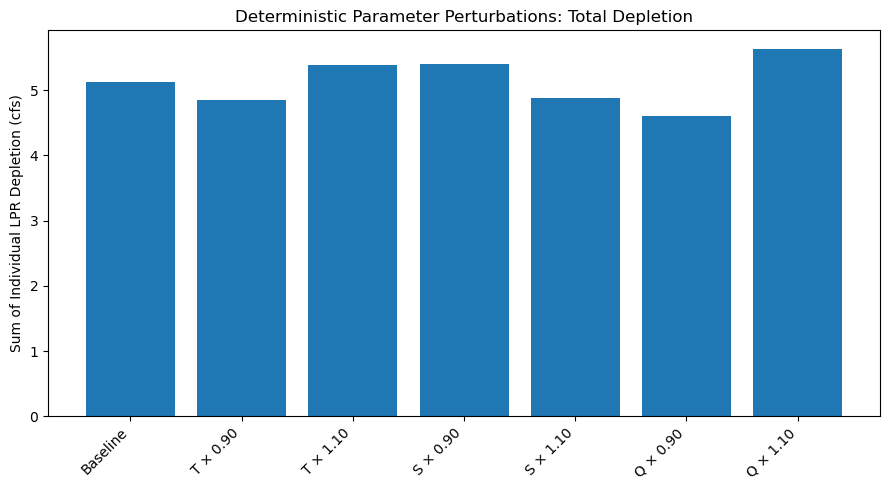

In [6]:
plot_df = scenario_summary.copy()
plot_df["scenario_label"] = plot_df["scenario"].apply(clean_scenario_label)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["scenario_label"], plot_df["sum_individual_depletion_cfs"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Sum of Individual LPR Depletion (cfs)")
plt.title("Deterministic Parameter Perturbations: Total Depletion")
plt.tight_layout()

save_figure(
    "A1_total_depletion_by_deterministic_scenario.png",
    "Sum of individual LPR depletion for baseline and one-at-a-time T, S, and Q perturbations.",
)
plt.show()


## 7. Figure A2: Mean depletion potential by deterministic scenario

Saved: results/pycap_runs/report_figures/figures/A2_mean_dp_by_deterministic_scenario.png


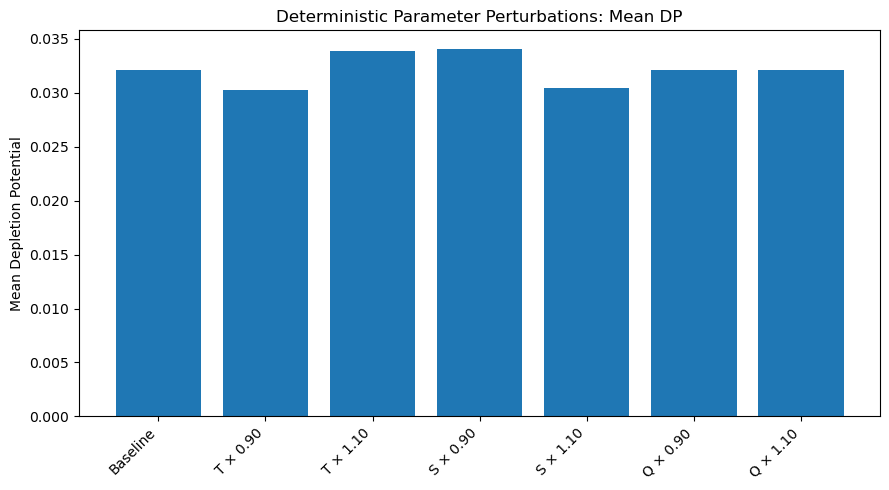

In [7]:
plt.figure(figsize=(9, 5))
plt.bar(plot_df["scenario_label"], plot_df["dp_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Depletion Potential")
plt.title("Deterministic Parameter Perturbations: Mean DP")
plt.tight_layout()

save_figure(
    "A2_mean_dp_by_deterministic_scenario.png",
    "Mean depletion potential for baseline and one-at-a-time T, S, and Q perturbations.",
)
plt.show()


## 8. Figure A3: Number of wells above DP = 0.20 by deterministic scenario

Saved: results/pycap_runs/report_figures/figures/A3_wells_above_dp020_by_deterministic_scenario.png


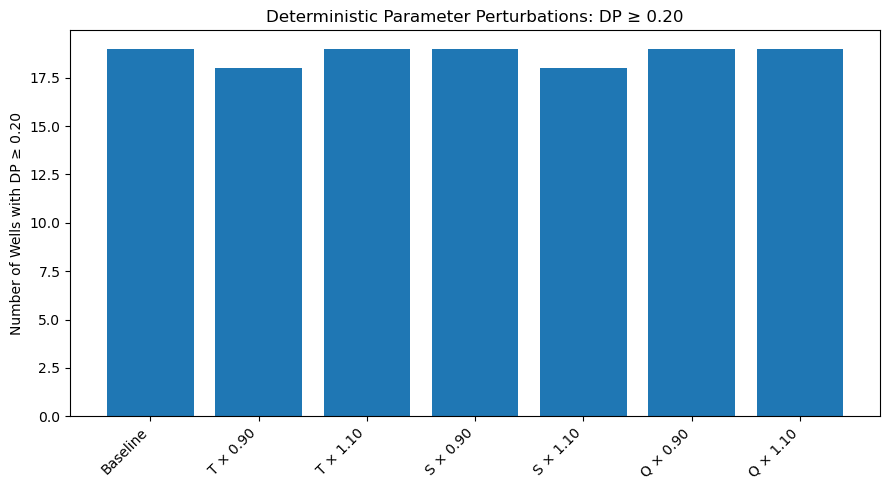

,scenario,parameter,factor,DP_threshold,wells_at_or_above_threshold,fraction_of_wells,scenario_label
4,baseline,none,1.0,0.2,19,0.058104,Baseline
10,T_low_90,T,0.9,0.2,18,0.055046,T × 0.90
16,T_high_110,T,1.1,0.2,19,0.058104,T × 1.10
22,S_low_90,S,0.9,0.2,19,0.058104,S × 0.90
28,S_high_110,S,1.1,0.2,18,0.055046,S × 1.10
34,Q_low_90,Q,0.9,0.2,19,0.058104,Q × 0.90
40,Q_high_110,Q,1.1,0.2,19,0.058104,Q × 1.10


In [8]:
dp020 = threshold_summary[threshold_summary["DP_threshold"] == 0.20].copy()
dp020["scenario_label"] = dp020["scenario"].apply(clean_scenario_label)

plt.figure(figsize=(9, 5))
plt.bar(dp020["scenario_label"], dp020["wells_at_or_above_threshold"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Wells with DP ≥ 0.20")
plt.title("Deterministic Parameter Perturbations: DP ≥ 0.20")
plt.tight_layout()

save_figure(
    "A3_wells_above_dp020_by_deterministic_scenario.png",
    "Number of wells with depletion potential at or above 0.20 for deterministic scenarios.",
)
plt.show()

dp020


## 9. Figure A4: Scenario DP compared to baseline DP

Saved: results/pycap_runs/report_figures/figures/A4_scenario_dp_vs_baseline_dp.png


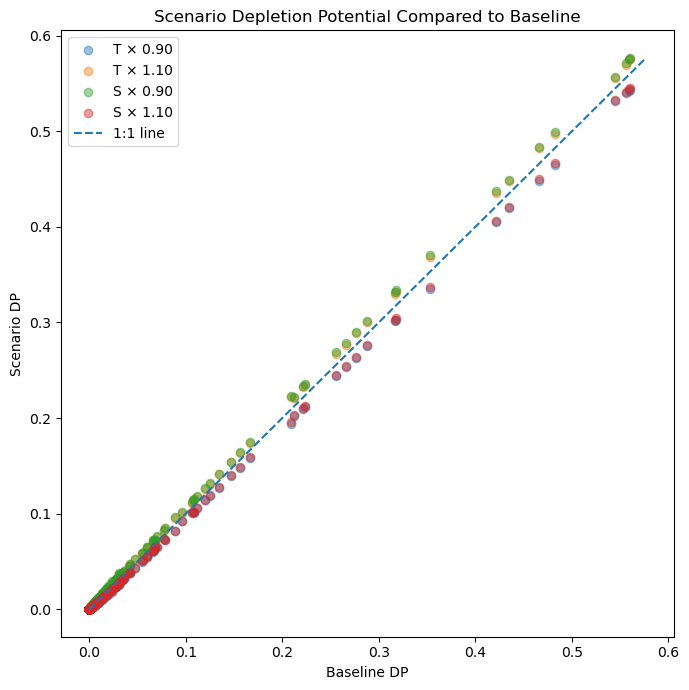

In [9]:
baseline_dp = all_dp[all_dp["scenario"] == "baseline"][
    ["well_key", "name", "Depletion_Potential"]
].rename(columns={"Depletion_Potential": "baseline_DP"})

scenario_compare = all_dp.merge(
    baseline_dp,
    on=["well_key", "name"],
    how="left",
)

selected_scenarios = ["T_low_90", "T_high_110", "S_low_90", "S_high_110"]

plt.figure(figsize=(7, 7))

for scenario in selected_scenarios:
    group = scenario_compare[scenario_compare["scenario"] == scenario].dropna(
        subset=["baseline_DP", "Depletion_Potential"]
    )
    plt.scatter(
        group["baseline_DP"],
        group["Depletion_Potential"],
        alpha=0.45,
        label=clean_scenario_label(scenario),
    )

max_value = max(
    scenario_compare["baseline_DP"].max(),
    scenario_compare["Depletion_Potential"].max(),
)
plt.plot([0, max_value], [0, max_value], linestyle="--", label="1:1 line")
plt.xlabel("Baseline DP")
plt.ylabel("Scenario DP")
plt.title("Scenario Depletion Potential Compared to Baseline")
plt.legend()
plt.tight_layout()

save_figure(
    "A4_scenario_dp_vs_baseline_dp.png",
    "Well-level depletion potential under T and S perturbations compared to baseline depletion potential.",
)
plt.show()


# Figure Set B — Selected-well sensitivity results

## 10. Figure B1: Selected wells with largest DP sensitivity

Saved: results/pycap_runs/report_figures/figures/B1_selected_well_largest_dp_sensitivity.png


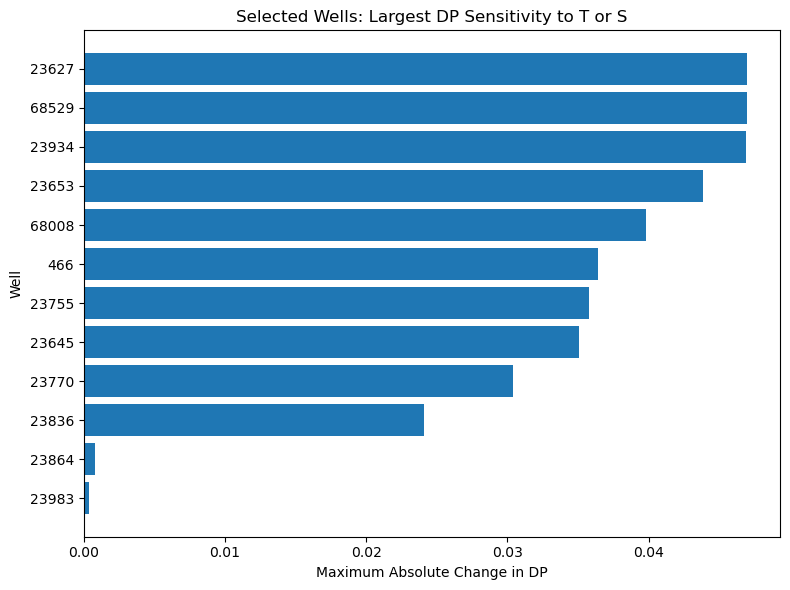

,well_key,name,max_abs_delta_DP
9,well_23983,23983,0.000391
6,well_23864,23864,0.000830
5,well_23836,23836,0.024086
4,well_23770,23770,0.030382
1,well_23645,23645,0.035062
3,well_23755,23755,0.035779
10,well_466,466,0.036385
11,well_68008,68008,0.039787
2,well_23653,23653,0.043866
8,well_23934,23934,0.046900


In [10]:
sensitivity_plot = selected_sensitivity[
    selected_sensitivity["parameter"].isin(["T", "S"])
].copy()

# Use the maximum sensitivity per well across T and S for a readable figure.
sensitivity_top = (
    sensitivity_plot
    .groupby(["well_key", "name"], as_index=False)
    .agg(max_abs_delta_DP=("max_abs_delta_DP", "max"))
    .sort_values("max_abs_delta_DP", ascending=False)
    .head(12)
    .sort_values("max_abs_delta_DP")
)

plt.figure(figsize=(8, 6))
plt.barh(sensitivity_top["name"].astype(str), sensitivity_top["max_abs_delta_DP"])
plt.xlabel("Maximum Absolute Change in DP")
plt.ylabel("Well")
plt.title("Selected Wells: Largest DP Sensitivity to T or S")
plt.tight_layout()

save_figure(
    "B1_selected_well_largest_dp_sensitivity.png",
    "Selected wells with largest depletion-potential sensitivity to transmissivity or storage perturbations.",
)
plt.show()

sensitivity_top


## 11. Figure B2: Selected well DP response to T

Saved: results/pycap_runs/report_figures/figures/B2_selected_wells_dp_response_to_T.png


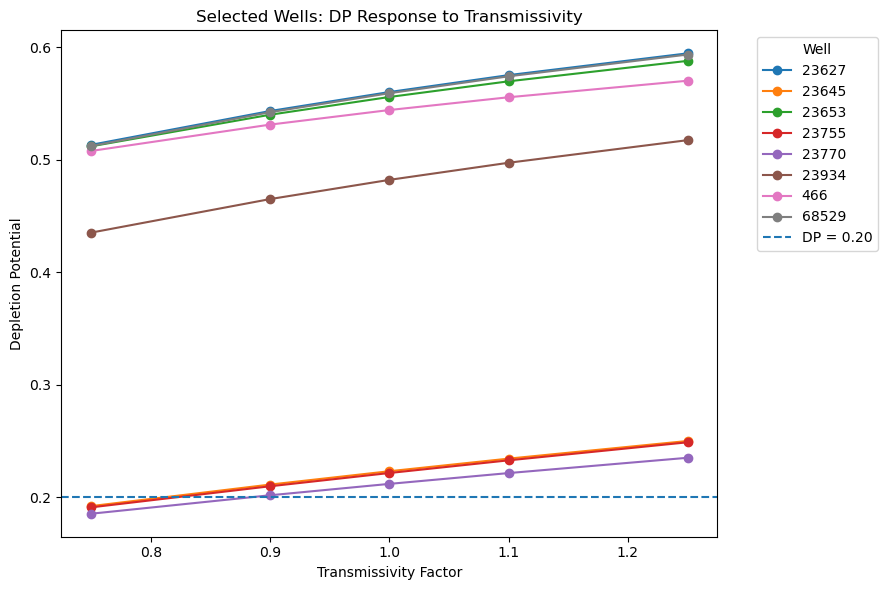

In [11]:
# Use top 8 selected wells by baseline DP to keep the figure readable.
top_plot_wells = (
    selected_wells
    .sort_values("Depletion_Potential", ascending=False)
    .head(min(8, len(selected_wells)))["well_key"]
    .tolist()
)

t_response = selected_comparisons[
    (selected_comparisons["parameter"] == "T")
    & (selected_comparisons["well_key"].isin(top_plot_wells))
].copy()

plt.figure(figsize=(9, 6))

for well_key, group in t_response.groupby("well_key"):
    group = group.sort_values("factor")
    well_name = group["name"].iloc[0]
    plt.plot(group["factor"], group["Depletion_Potential"], marker="o", label=str(well_name))

add_dp_threshold_line(0.20)
plt.xlabel("Transmissivity Factor")
plt.ylabel("Depletion Potential")
plt.title("Selected Wells: DP Response to Transmissivity")
plt.legend(title="Well", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

save_figure(
    "B2_selected_wells_dp_response_to_T.png",
    "Depletion-potential response to transmissivity perturbations for selected high-impact wells.",
)
plt.show()


## 12. Figure B3: Selected well DP response to S

Saved: results/pycap_runs/report_figures/figures/B3_selected_wells_dp_response_to_S.png


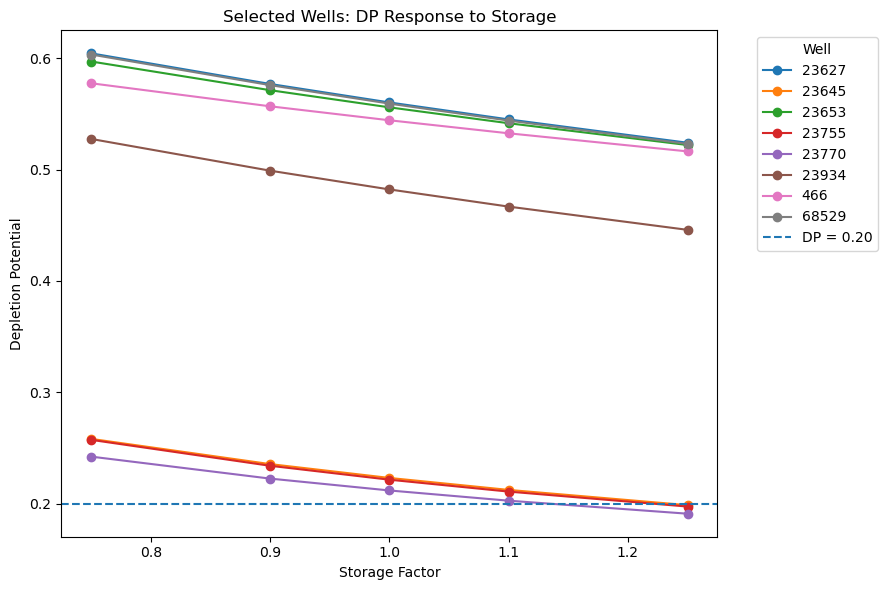

In [12]:
s_response = selected_comparisons[
    (selected_comparisons["parameter"] == "S")
    & (selected_comparisons["well_key"].isin(top_plot_wells))
].copy()

plt.figure(figsize=(9, 6))

for well_key, group in s_response.groupby("well_key"):
    group = group.sort_values("factor")
    well_name = group["name"].iloc[0]
    plt.plot(group["factor"], group["Depletion_Potential"], marker="o", label=str(well_name))

add_dp_threshold_line(0.20)
plt.xlabel("Storage Factor")
plt.ylabel("Depletion Potential")
plt.title("Selected Wells: DP Response to Storage")
plt.legend(title="Well", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

save_figure(
    "B3_selected_wells_dp_response_to_S.png",
    "Depletion-potential response to storage perturbations for selected high-impact wells.",
)
plt.show()


## 13. Figure B4: Threshold-crossing selected wells

Saved: results/pycap_runs/report_figures/figures/B4_selected_well_dp020_threshold_crossings.png


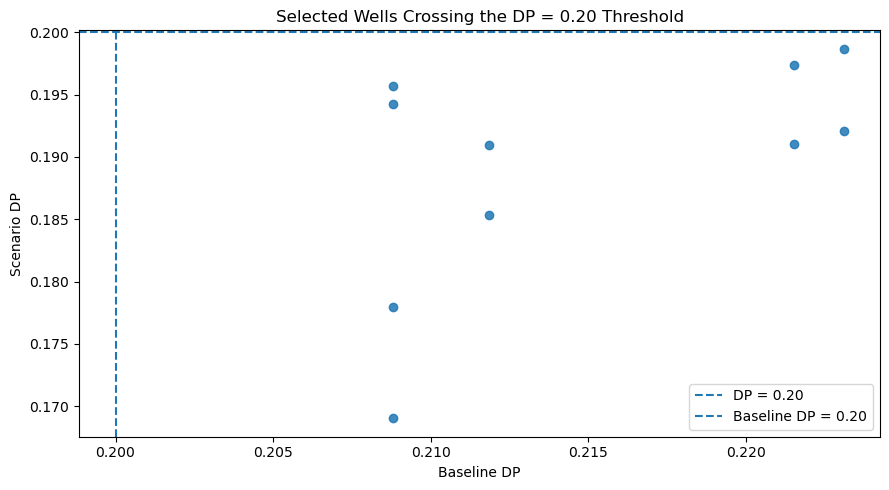

,scenario,parameter,factor,well_key,name,baseline_DP,Depletion_Potential,baseline_above_0_20,scenario_above_0_20
0,S_125,S,1.25,well_23645,23645,0.223110,0.198677,True,False
1,T_075,T,0.75,well_23645,23645,0.223110,0.192108,True,False
2,S_125,S,1.25,well_23755,23755,0.221531,0.197410,True,False
3,T_075,T,0.75,well_23755,23755,0.221531,0.191010,True,False
4,S_125,S,1.25,well_23770,23770,0.211866,0.190994,True,False
5,T_075,T,0.75,well_23770,23770,0.211866,0.185342,True,False
6,S_110,S,1.10,well_68008,68008,0.208813,0.195672,True,False
7,S_125,S,1.25,well_68008,68008,0.208813,0.177963,True,False
8,T_075,T,0.75,well_68008,68008,0.208813,0.169026,True,False
9,T_090,T,0.90,well_68008,68008,0.208813,0.194282,True,False


In [13]:
if selected_threshold_crossings.empty:
    print("No selected wells crossed the DP = 0.20 threshold.")
else:
    threshold_plot = selected_threshold_crossings.copy()
    threshold_plot["scenario_label"] = threshold_plot["parameter"] + " × " + threshold_plot["factor"].astype(str)

    plt.figure(figsize=(9, 5))
    plt.scatter(
        threshold_plot["baseline_DP"],
        threshold_plot["Depletion_Potential"],
        alpha=0.85,
    )
    add_dp_threshold_line(0.20)
    plt.axvline(0.20, linestyle="--", label="Baseline DP = 0.20")
    plt.xlabel("Baseline DP")
    plt.ylabel("Scenario DP")
    plt.title("Selected Wells Crossing the DP = 0.20 Threshold")
    plt.legend()
    plt.tight_layout()

    save_figure(
        "B4_selected_well_dp020_threshold_crossings.png",
        "Selected wells whose depletion-potential classification changes relative to the 0.20 threshold.",
    )
    plt.show()

selected_threshold_crossings


# Figure Set C — Monte Carlo uncertainty results

## 14. Figure C1: Monte Carlo distribution of total depletion

Saved: results/pycap_runs/report_figures/figures/C1_monte_carlo_total_depletion_distribution.png


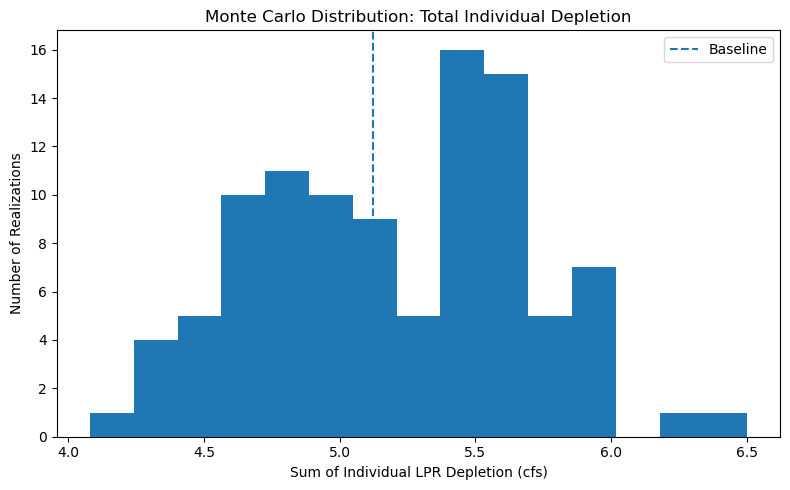

In [14]:
baseline_total_depletion = baseline_vs_mc.loc[
    baseline_vs_mc["metric"] == "sum_individual_depletion_cfs",
    "baseline_value",
].iloc[0]

plt.figure(figsize=(8, 5))
plt.hist(mc_summary["sum_individual_depletion_cfs"], bins=15)
plt.axvline(baseline_total_depletion, linestyle="--", label="Baseline")
plt.xlabel("Sum of Individual LPR Depletion (cfs)")
plt.ylabel("Number of Realizations")
plt.title("Monte Carlo Distribution: Total Individual Depletion")
plt.legend()
plt.tight_layout()

save_figure(
    "C1_monte_carlo_total_depletion_distribution.png",
    "Monte Carlo distribution of summed individual LPR depletion with baseline value shown.",
)
plt.show()


## 15. Figure C2: Monte Carlo distribution of mean DP

Saved: results/pycap_runs/report_figures/figures/C2_monte_carlo_mean_dp_distribution.png


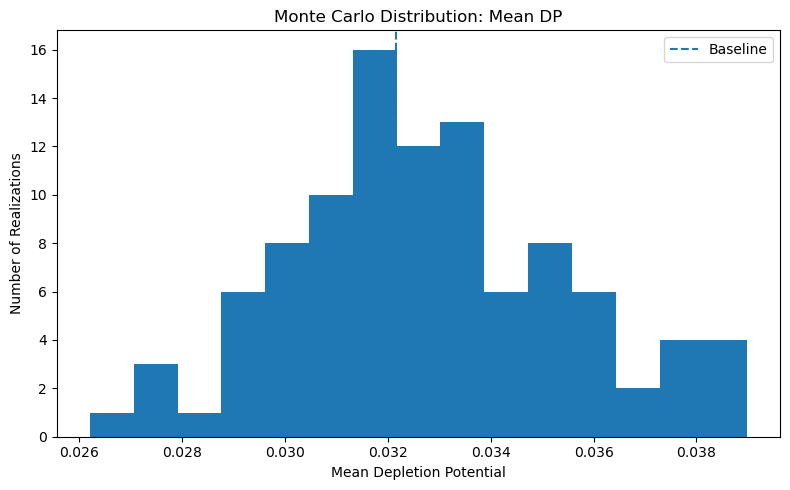

In [15]:
baseline_mean_dp = baseline_vs_mc.loc[
    baseline_vs_mc["metric"] == "dp_mean",
    "baseline_value",
].iloc[0]

plt.figure(figsize=(8, 5))
plt.hist(mc_summary["dp_mean"], bins=15)
plt.axvline(baseline_mean_dp, linestyle="--", label="Baseline")
plt.xlabel("Mean Depletion Potential")
plt.ylabel("Number of Realizations")
plt.title("Monte Carlo Distribution: Mean DP")
plt.legend()
plt.tight_layout()

save_figure(
    "C2_monte_carlo_mean_dp_distribution.png",
    "Monte Carlo distribution of mean depletion potential with baseline value shown.",
)
plt.show()


## 16. Figure C3: T and S factors versus mean DP

Saved: results/pycap_runs/report_figures/figures/C3_monte_carlo_T_S_factors_vs_mean_dp.png


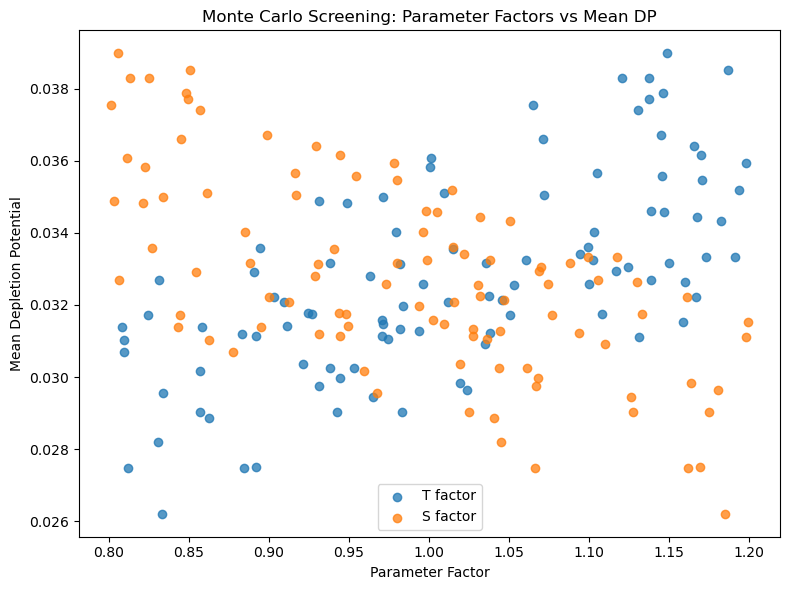

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(mc_summary["T_factor"], mc_summary["dp_mean"], alpha=0.75, label="T factor")
plt.scatter(mc_summary["S_factor"], mc_summary["dp_mean"], alpha=0.75, label="S factor")
plt.xlabel("Parameter Factor")
plt.ylabel("Mean Depletion Potential")
plt.title("Monte Carlo Screening: Parameter Factors vs Mean DP")
plt.legend()
plt.tight_layout()

save_figure(
    "C3_monte_carlo_T_S_factors_vs_mean_dp.png",
    "Monte Carlo screening plot showing association between sampled T/S factors and mean depletion potential.",
)
plt.show()


## 17. Figure C4: Wells above DP = 0.20 in Monte Carlo realizations

Saved: results/pycap_runs/report_figures/figures/C4_monte_carlo_wells_above_dp020_distribution.png


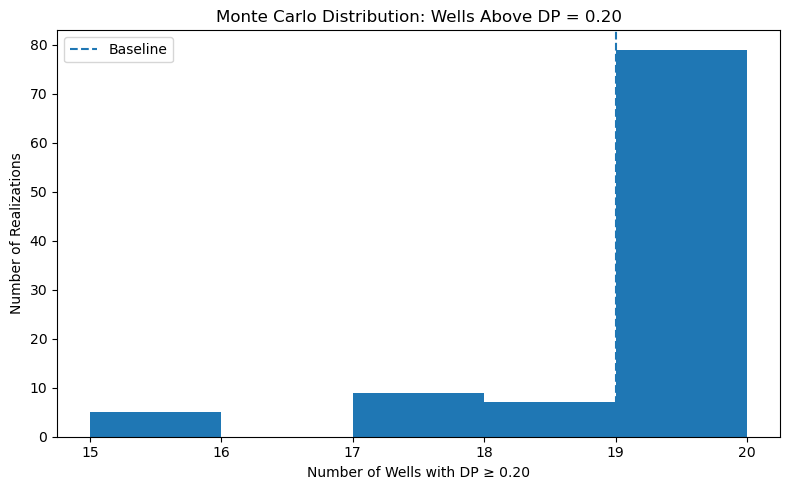

In [17]:
baseline_dp020_count = baseline_vs_mc.loc[
    baseline_vs_mc["metric"] == "wells_dp_ge_0_20",
    "baseline_value",
].iloc[0]

plt.figure(figsize=(8, 5))
plt.hist(mc_summary["wells_dp_ge_0_20"], bins=range(
    int(mc_summary["wells_dp_ge_0_20"].min()),
    int(mc_summary["wells_dp_ge_0_20"].max()) + 2,
))
plt.axvline(baseline_dp020_count, linestyle="--", label="Baseline")
plt.xlabel("Number of Wells with DP ≥ 0.20")
plt.ylabel("Number of Realizations")
plt.title("Monte Carlo Distribution: Wells Above DP = 0.20")
plt.legend()
plt.tight_layout()

save_figure(
    "C4_monte_carlo_wells_above_dp020_distribution.png",
    "Monte Carlo distribution of the number of wells with depletion potential at or above 0.20.",
)
plt.show()


## 18. Figure C5: Top-well DP uncertainty ranges

Saved: results/pycap_runs/report_figures/figures/C5_top_well_monte_carlo_dp_ranges.png


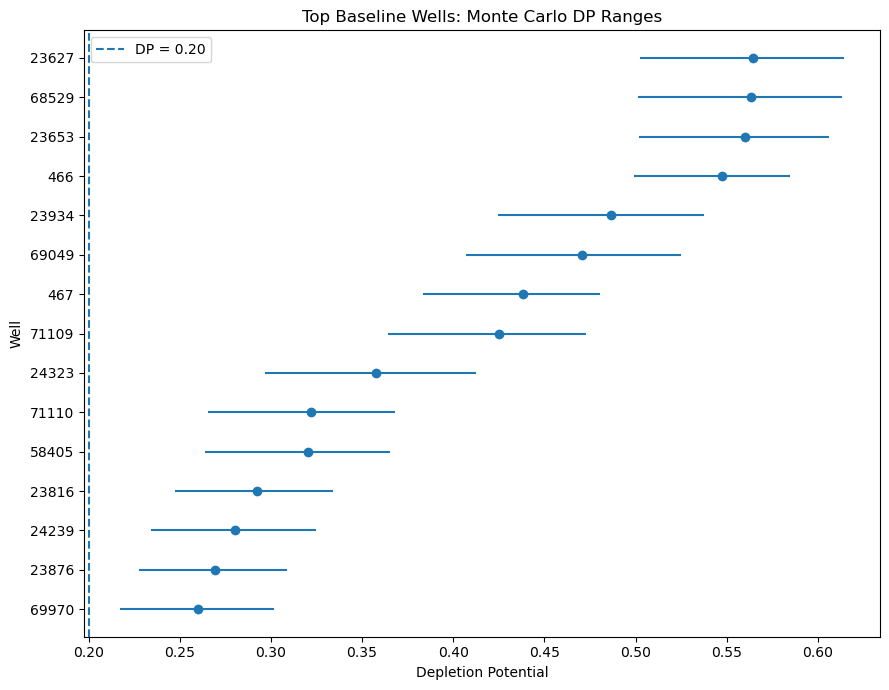

In [18]:
top_plot = top25_uncertainty.head(15).copy()
top_plot = top_plot.sort_values("dp_mean")

plt.figure(figsize=(9, 7))
plt.errorbar(
    top_plot["dp_mean"],
    top_plot["name"].astype(str),
    xerr=[
        top_plot["dp_mean"] - top_plot["dp_min"],
        top_plot["dp_max"] - top_plot["dp_mean"],
    ],
    fmt="o",
)
plt.axvline(0.20, linestyle="--", label="DP = 0.20")
plt.xlabel("Depletion Potential")
plt.ylabel("Well")
plt.title("Top Baseline Wells: Monte Carlo DP Ranges")
plt.legend()
plt.tight_layout()

save_figure(
    "C5_top_well_monte_carlo_dp_ranges.png",
    "Monte Carlo depletion-potential ranges for the top baseline wells.",
)
plt.show()


# Figure Set D — Existing Pareto front results

These figures show the imported PEST++-MOU Pareto fronts directly.

They are different from the Pareto-member uncertainty figures below:

- **Pareto front plots** show the optimized tradeoff fronts that already existed in the LPR project.
- **Pareto-member uncertainty plots** reevaluate those members under PyCAP uncertainty scenarios.

The main depletion/pumping Pareto front uses:

```text
obj_well                  → pumping objective
lpr:total_combined:bdpl   → depletion objective
```

The plotting code below automatically creates a more intuitive pumping axis if `obj_well` is stored as a negative minimization objective.


## D0. Load combined Pareto-front tables from 06a

In [19]:
combined_depletion_fronts_path = require_file(
    PARETO_TABLES_DIR / "combined_depletion_q_pareto_fronts.csv",
    "06a combined depletion-q Pareto fronts",
)

combined_depletion_fronts = pd.read_csv(combined_depletion_fronts_path)

# Fish/dollars fronts are optional because they depend on whether 06a detected those objective columns.
combined_fish_fronts_path = PARETO_TABLES_DIR / "combined_fish_dollars_pareto_fronts.csv"
if combined_fish_fronts_path.exists():
    combined_fish_fronts = pd.read_csv(combined_fish_fronts_path)
    print(f"Loaded optional fish/dollars front table: {combined_fish_fronts_path.relative_to(PROJECT_ROOT)}")
else:
    combined_fish_fronts = None
    print("Optional fish/dollars front table was not found. Skipping fish/dollars Pareto plot later.")

print(f"Loaded depletion-q Pareto fronts: {combined_depletion_fronts.shape}")
display(combined_depletion_fronts.head())


Loaded optional fish/dollars front table: results/pycap_runs/pareto_uncertainty_comparison/tables/combined_fish_dollars_pareto_fronts.csv
Loaded depletion-q Pareto fronts: (11512, 14)


,generation,member,lpr:total_combined:bdpl,obj_well,nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance,family,run_case,table_type,computed_nondominated
0,0,0,4.68365,4341.73,1,7.771370e-02,14.02910,14.02910,1,-999,depletion_q,baseline,pareto_summary,True
1,0,1,4.43955,3931.63,1,1.000000e+30,0.00419,0.00419,1,-999,depletion_q,baseline,pareto_summary,False
2,0,2,4.71985,4347.88,3,3.813990e-01,14.03540,14.03540,1,-999,depletion_q,baseline,pareto_summary,False
3,0,3,4.62910,4238.04,2,2.032440e-01,9.02132,9.02132,1,-999,depletion_q,baseline,pareto_summary,False
4,0,4,4.58784,4184.74,2,1.168040e-01,9.03037,9.03037,1,-999,depletion_q,baseline,pareto_summary,False


## D1. Existing depletion/pumping Pareto fronts

This figure compares the existing optimized Pareto fronts for:

```text
baseline
T -10%
T +10%
```

This is the direct optimization result imported from the LPR/Pest++-MOU workflow.


Saved: results/pycap_runs/report_figures/figures/D0_existing_depletion_q_pareto_fronts.png


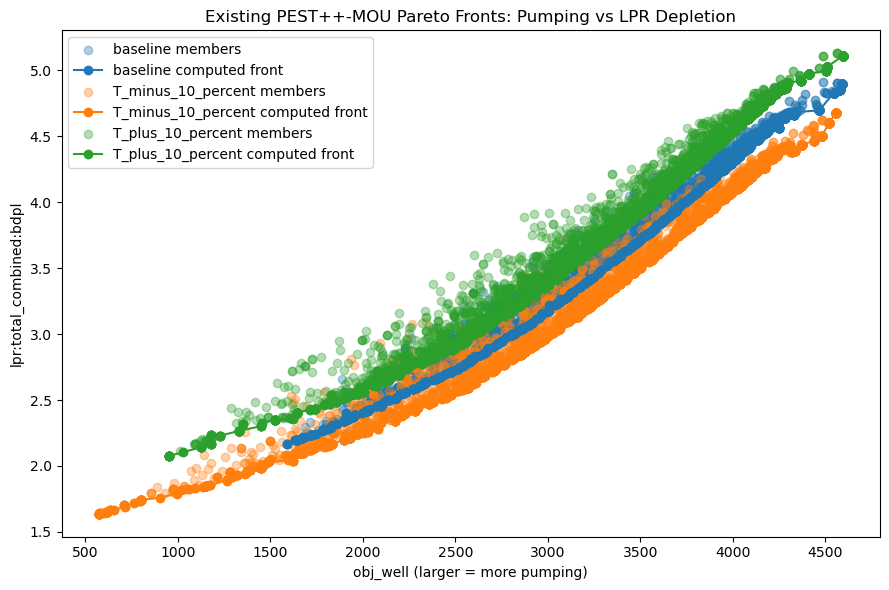

In [20]:
PARETO_PUMPING_COL = "obj_well"
PARETO_DEPLETION_COL = "lpr:total_combined:bdpl"

if PARETO_PUMPING_COL not in combined_depletion_fronts.columns:
    raise KeyError(f"Missing expected pumping column: {PARETO_PUMPING_COL}")
if PARETO_DEPLETION_COL not in combined_depletion_fronts.columns:
    raise KeyError(f"Missing expected depletion column: {PARETO_DEPLETION_COL}")

plot_fronts = combined_depletion_fronts.copy()

# If obj_well is stored as a negative minimization objective, flip it for a more intuitive axis.
# This keeps the raw obj_well column unchanged.
if plot_fronts[PARETO_PUMPING_COL].median() < 0:
    plot_fronts["plot_pumping"] = -plot_fronts[PARETO_PUMPING_COL]
    pumping_axis_label = f"-{PARETO_PUMPING_COL} (larger = more pumping)"
else:
    plot_fronts["plot_pumping"] = plot_fronts[PARETO_PUMPING_COL]
    pumping_axis_label = f"{PARETO_PUMPING_COL} (larger = more pumping)"

run_order = ["baseline", "T_minus_10_percent", "T_plus_10_percent"]

plt.figure(figsize=(9, 6))

for run_case in run_order:
    group = plot_fronts[plot_fronts["run_case"] == run_case].copy()
    if group.empty:
        continue

    plt.scatter(
        group["plot_pumping"],
        group[PARETO_DEPLETION_COL],
        alpha=0.35,
        label=f"{run_case} members",
    )

    if "computed_nondominated" in group.columns:
        front = group[group["computed_nondominated"]].sort_values("plot_pumping")
        if not front.empty:
            plt.plot(
                front["plot_pumping"],
                front[PARETO_DEPLETION_COL],
                marker="o",
                linewidth=1.5,
                label=f"{run_case} computed front",
            )

plt.xlabel(pumping_axis_label)
plt.ylabel(PARETO_DEPLETION_COL)
plt.title("Existing PEST++-MOU Pareto Fronts: Pumping vs LPR Depletion")
plt.legend()
plt.tight_layout()

save_figure(
    "D0_existing_depletion_q_pareto_fronts.png",
    "Existing PEST++-MOU depletion/pumping Pareto fronts for baseline and T ±10% cases.",
)
plt.show()


## D2. Existing Pareto front envelope summary

This figure summarizes the range of depletion objective values on each imported Pareto front.


Saved: results/pycap_runs/report_figures/tables/existing_pareto_front_envelope_summary.csv
Saved: results/pycap_runs/report_figures/figures/D0b_existing_pareto_front_depletion_ranges.png


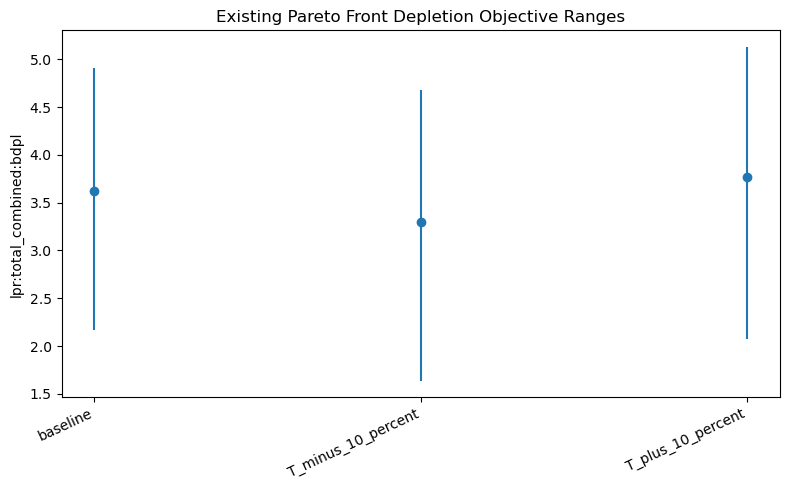

,run_case,pumping_min,pumping_mean,pumping_max,depletion_min,depletion_mean,depletion_max,n_members
0,T_minus_10_percent,572.591,3132.168749,4556.68,1.63921,3.303263,4.67628,3838
1,T_plus_10_percent,953.523,3225.483030,4594.03,2.07740,3.771105,5.12943,3837
2,baseline,1592.130,3300.083461,4589.24,2.16882,3.621230,4.90967,3837


In [21]:
front_envelope = (
    plot_fronts
    .groupby("run_case", as_index=False)
    .agg(
        pumping_min=("plot_pumping", "min"),
        pumping_mean=("plot_pumping", "mean"),
        pumping_max=("plot_pumping", "max"),
        depletion_min=(PARETO_DEPLETION_COL, "min"),
        depletion_mean=(PARETO_DEPLETION_COL, "mean"),
        depletion_max=(PARETO_DEPLETION_COL, "max"),
        n_members=("run_case", "size"),
    )
)

front_envelope_path = REPORT_TABLES_DIR / "existing_pareto_front_envelope_summary.csv"
front_envelope.to_csv(front_envelope_path, index=False)
print(f"Saved: {front_envelope_path.relative_to(PROJECT_ROOT)}")

front_envelope_plot = front_envelope.set_index("run_case").loc[
    [case for case in run_order if case in front_envelope["run_case"].values]
].reset_index()

plt.figure(figsize=(8, 5))
plt.errorbar(
    front_envelope_plot["run_case"],
    front_envelope_plot["depletion_mean"],
    yerr=[
        front_envelope_plot["depletion_mean"] - front_envelope_plot["depletion_min"],
        front_envelope_plot["depletion_max"] - front_envelope_plot["depletion_mean"],
    ],
    fmt="o",
)
plt.xticks(rotation=25, ha="right")
plt.ylabel(PARETO_DEPLETION_COL)
plt.title("Existing Pareto Front Depletion Objective Ranges")
plt.tight_layout()

save_figure(
    "D0b_existing_pareto_front_depletion_ranges.png",
    "Range of depletion objective values across imported baseline and T ±10% Pareto fronts.",
)
plt.show()

front_envelope


## D3. Optional fish/dollars Pareto front plot

This optional figure is created only if 06a successfully exported `combined_fish_dollars_pareto_fronts.csv`.


Fish-like columns: ['fish_prob']
Dollar/ag-like columns: ['ag_receipts']
Saved: results/pycap_runs/report_figures/figures/D0c_existing_fish_dollars_pareto_fronts.png


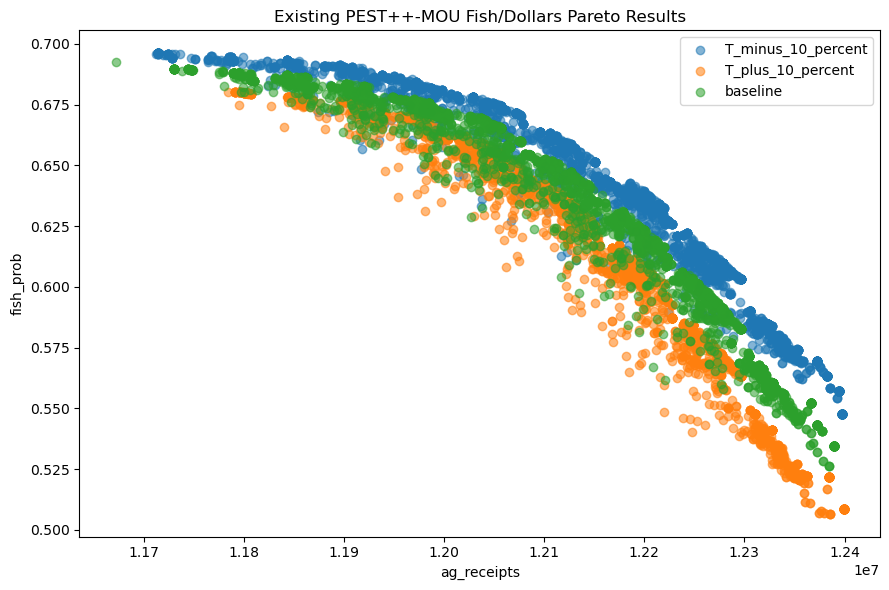

In [22]:
if combined_fish_fronts is None:
    print("Skipping fish/dollars Pareto plot because the combined fish/dollars front table was not available.")
else:
    fish_candidates = [col for col in combined_fish_fronts.columns if any(term in col.lower() for term in ["fish", "trout", "likelihood", "prob"])]
    dollar_candidates = [col for col in combined_fish_fronts.columns if any(term in col.lower() for term in ["dollar", "receipt", "ag", "economic", "revenue"])]

    print("Fish-like columns:", fish_candidates)
    print("Dollar/ag-like columns:", dollar_candidates)

    if fish_candidates and dollar_candidates:
        fish_col = fish_candidates[0]
        dollars_col = dollar_candidates[0]

        plt.figure(figsize=(9, 6))

        for run_case, group in combined_fish_fronts.groupby("run_case"):
            plt.scatter(
                group[dollars_col],
                group[fish_col],
                alpha=0.55,
                label=run_case,
            )

        plt.xlabel(dollars_col)
        plt.ylabel(fish_col)
        plt.title("Existing PEST++-MOU Fish/Dollars Pareto Results")
        plt.legend()
        plt.tight_layout()

        save_figure(
            "D0c_existing_fish_dollars_pareto_fronts.png",
            "Existing PEST++-MOU fish/agriculture or fish/dollars Pareto results for baseline and T ±10% cases.",
        )
        plt.show()
    else:
        print("Could not automatically identify fish and dollar/agriculture objective columns.")


# Figure Set E — Pareto-member uncertainty results

## 19. Figure D1: Pareto-member streamflow uncertainty versus pumping

Saved: results/pycap_runs/report_figures/figures/D1_pareto_member_streamflow_uncertainty_vs_pumping.png


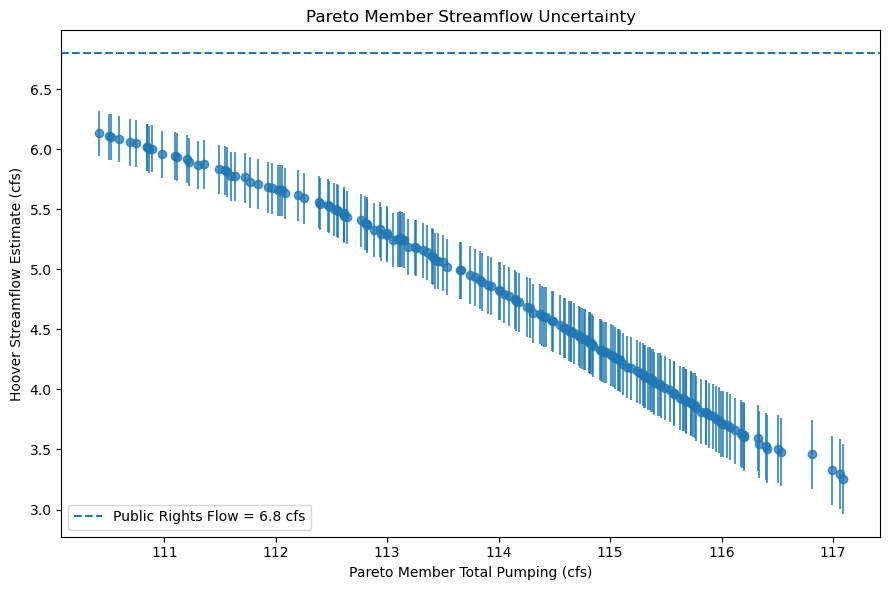

In [23]:
pareto_plot = pareto_robustness.sort_values("member_total_pumping_cfs").copy()

plt.figure(figsize=(9, 6))
plt.errorbar(
    pareto_plot["member_total_pumping_cfs"],
    pareto_plot["streamflow_mean"],
    yerr=[
        pareto_plot["streamflow_mean"] - pareto_plot["streamflow_min"],
        pareto_plot["streamflow_max"] - pareto_plot["streamflow_mean"],
    ],
    fmt="o",
    alpha=0.75,
)

add_prf_line()
plt.xlabel("Pareto Member Total Pumping (cfs)")
plt.ylabel("Hoover Streamflow Estimate (cfs)")
plt.title("Pareto Member Streamflow Uncertainty")
plt.legend()
plt.tight_layout()

save_figure(
    "D1_pareto_member_streamflow_uncertainty_vs_pumping.png",
    "Streamflow uncertainty range for each imported Pareto member as a function of total pumping.",
)
plt.show()


## 20. Figure D2: Pareto-member depletion uncertainty versus pumping

Saved: results/pycap_runs/report_figures/figures/D2_pareto_member_depletion_uncertainty_vs_pumping.png


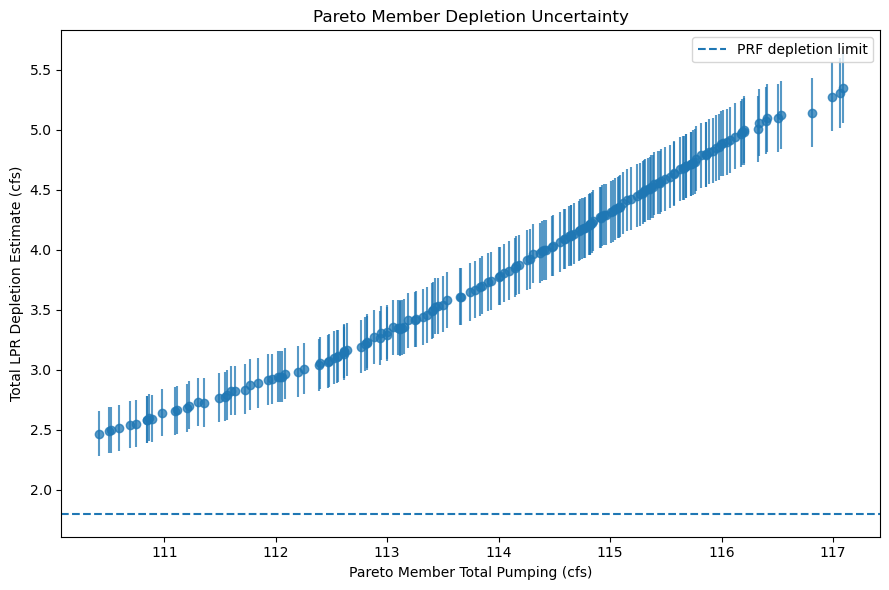

In [24]:
plt.figure(figsize=(9, 6))
plt.errorbar(
    pareto_plot["member_total_pumping_cfs"],
    pareto_plot["depletion_mean"],
    yerr=[
        pareto_plot["depletion_mean"] - pareto_plot["depletion_min"],
        pareto_plot["depletion_max"] - pareto_plot["depletion_mean"],
    ],
    fmt="o",
    alpha=0.75,
)

plt.axhline(PRF_ALLOWED_DEPLETION_CFS, linestyle="--", label="PRF depletion limit")
plt.xlabel("Pareto Member Total Pumping (cfs)")
plt.ylabel("Total LPR Depletion Estimate (cfs)")
plt.title("Pareto Member Depletion Uncertainty")
plt.legend()
plt.tight_layout()

save_figure(
    "D2_pareto_member_depletion_uncertainty_vs_pumping.png",
    "Depletion uncertainty range for each imported Pareto member as a function of total pumping.",
)
plt.show()


## 21. Figure D3: Best Pareto-member streamflow by uncertainty scenario

Saved: results/pycap_runs/report_figures/figures/D3_best_pareto_member_streamflow_by_scenario.png


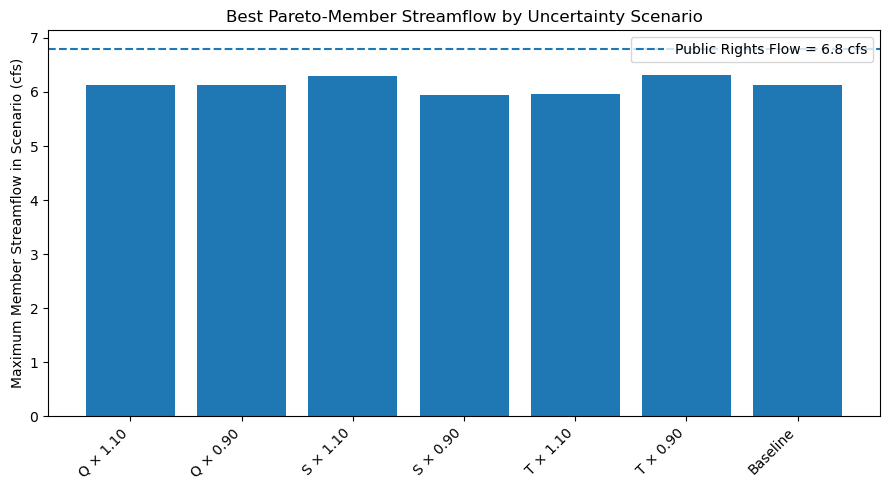

In [25]:
scenario_plot = pareto_scenario_summary.copy()
scenario_plot["scenario_label"] = scenario_plot["scenario"].apply(clean_scenario_label)

plt.figure(figsize=(9, 5))
plt.bar(scenario_plot["scenario_label"], scenario_plot["max_streamflow"])
add_prf_line()
plt.xticks(rotation=45, ha="right")
plt.ylabel("Maximum Member Streamflow in Scenario (cfs)")
plt.title("Best Pareto-Member Streamflow by Uncertainty Scenario")
plt.legend()
plt.tight_layout()

save_figure(
    "D3_best_pareto_member_streamflow_by_scenario.png",
    "Best member streamflow by uncertainty scenario compared with the Public Rights Flow threshold.",
)
plt.show()


## 22. Figure D4: Pareto members meeting PRF by scenario

Saved: results/pycap_runs/report_figures/figures/D4_pareto_members_meeting_prf_by_scenario.png


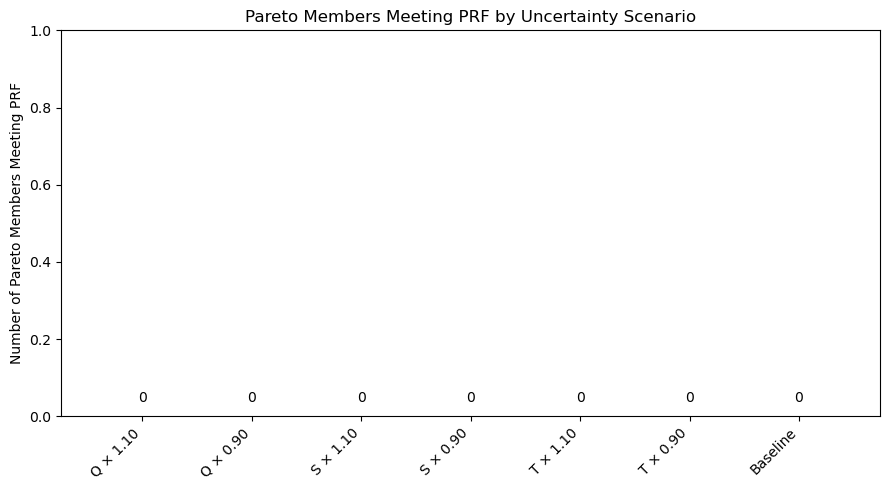

In [26]:
plt.figure(figsize=(9, 5))
bars = plt.bar(
    scenario_plot["scenario_label"],
    scenario_plot["members_meeting_prf"],
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Pareto Members Meeting PRF")
plt.title("Pareto Members Meeting PRF by Uncertainty Scenario")
plt.ylim(0, max(1, scenario_plot["members_meeting_prf"].max() + 1))

for bar, value in zip(bars, scenario_plot["members_meeting_prf"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        0.03,
        str(int(value)),
        ha="center",
        va="bottom",
    )

plt.tight_layout()

save_figure(
    "D4_pareto_members_meeting_prf_by_scenario.png",
    "Count of imported Pareto members meeting the Public Rights Flow threshold under each uncertainty scenario.",
)
plt.show()


# Figure Set F — One-page synthesis figures

## 23. Figure E1: Key uncertainty metrics summary

This figure combines the main numerical story into one compact set of bars.


Saved: results/pycap_runs/report_figures/figures/E1_key_dp_metrics_summary.png


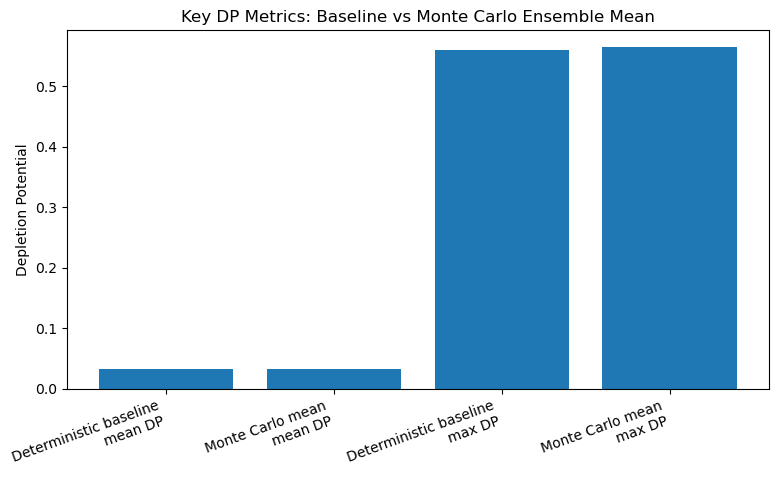

Saved: results/pycap_runs/report_figures/tables/key_dp_metrics_summary.csv


In [27]:
summary_metrics = pd.DataFrame(
    [
        {
            "metric": "Deterministic baseline\nmean DP",
            "value": scenario_summary.loc[scenario_summary["scenario"] == "baseline", "dp_mean"].iloc[0],
        },
        {
            "metric": "Monte Carlo mean\nmean DP",
            "value": mc_summary["dp_mean"].mean(),
        },
        {
            "metric": "Deterministic baseline\nmax DP",
            "value": scenario_summary.loc[scenario_summary["scenario"] == "baseline", "dp_max"].iloc[0],
        },
        {
            "metric": "Monte Carlo mean\nmax DP",
            "value": mc_summary["dp_max"].mean(),
        },
    ]
)

plt.figure(figsize=(8, 5))
plt.bar(summary_metrics["metric"], summary_metrics["value"])
plt.ylabel("Depletion Potential")
plt.title("Key DP Metrics: Baseline vs Monte Carlo Ensemble Mean")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

save_figure(
    "E1_key_dp_metrics_summary.png",
    "Compact comparison of deterministic baseline DP metrics with Monte Carlo ensemble mean metrics.",
)
plt.show()

summary_metrics_path = REPORT_TABLES_DIR / "key_dp_metrics_summary.csv"
summary_metrics.to_csv(summary_metrics_path, index=False)
print(f"Saved: {summary_metrics_path.relative_to(PROJECT_ROOT)}")


## 24. Figure E2: Depletion and PRF framing

This figure summarizes the PRF-related framing for the Pareto-member results.


Saved: results/pycap_runs/report_figures/figures/E2_prf_depletion_framing.png


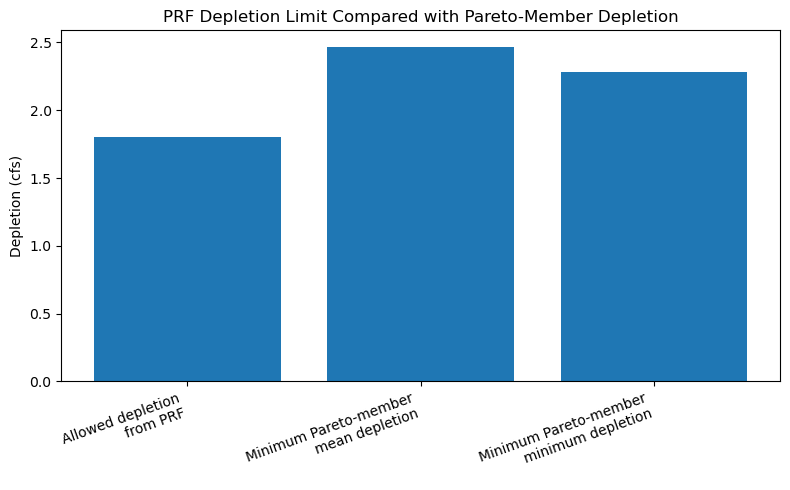

Saved: results/pycap_runs/report_figures/tables/prf_depletion_framing_summary.csv


In [28]:
prf_metrics = pd.DataFrame(
    [
        {
            "metric": "Allowed depletion\nfrom PRF",
            "value": PRF_ALLOWED_DEPLETION_CFS,
        },
        {
            "metric": "Minimum Pareto-member\nmean depletion",
            "value": pareto_robustness["depletion_mean"].min(),
        },
        {
            "metric": "Minimum Pareto-member\nminimum depletion",
            "value": pareto_robustness["depletion_min"].min(),
        },
    ]
)

plt.figure(figsize=(8, 5))
plt.bar(prf_metrics["metric"], prf_metrics["value"])
plt.ylabel("Depletion (cfs)")
plt.title("PRF Depletion Limit Compared with Pareto-Member Depletion")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

save_figure(
    "E2_prf_depletion_framing.png",
    "Comparison between allowed PRF depletion and the lowest reevaluated Pareto-member depletion estimates.",
)
plt.show()

prf_metrics_path = REPORT_TABLES_DIR / "prf_depletion_framing_summary.csv"
prf_metrics.to_csv(prf_metrics_path, index=False)
print(f"Saved: {prf_metrics_path.relative_to(PROJECT_ROOT)}")


## 25. Create figure manifest and caption starter table

In [29]:
figure_manifest_df = pd.DataFrame(figure_manifest)

figure_manifest_path = REPORT_TABLES_DIR / "figure_manifest.csv"
figure_manifest_df.to_csv(figure_manifest_path, index=False)

caption_rows = []

for i, row in figure_manifest_df.iterrows():
    caption_rows.append(
        {
            "figure_id": f"Figure {i + 1}",
            "figure_file": row["figure_file"],
            "draft_caption": row["description"],
        }
    )

caption_table = pd.DataFrame(caption_rows)

caption_table_path = REPORT_TABLES_DIR / "draft_figure_captions.csv"
caption_table.to_csv(caption_table_path, index=False)

print(f"Saved: {figure_manifest_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {caption_table_path.relative_to(PROJECT_ROOT)}")

caption_table


Saved: results/pycap_runs/report_figures/tables/figure_manifest.csv
Saved: results/pycap_runs/report_figures/tables/draft_figure_captions.csv


,figure_id,figure_file,draft_caption
0,Figure 1,A1_total_depletion_by_deterministic_scenario.png,Sum of individual LPR depletion for baseline a...
1,Figure 2,A2_mean_dp_by_deterministic_scenario.png,Mean depletion potential for baseline and one-...
2,Figure 3,A3_wells_above_dp020_by_deterministic_scenario...,Number of wells with depletion potential at or...
3,Figure 4,A4_scenario_dp_vs_baseline_dp.png,Well-level depletion potential under T and S p...
4,Figure 5,B1_selected_well_largest_dp_sensitivity.png,Selected wells with largest depletion-potentia...
5,Figure 6,B2_selected_wells_dp_response_to_T.png,Depletion-potential response to transmissivity...
6,Figure 7,B3_selected_wells_dp_response_to_S.png,Depletion-potential response to storage pertur...
7,Figure 8,B4_selected_well_dp020_threshold_crossings.png,Selected wells whose depletion-potential class...
8,Figure 9,C1_monte_carlo_total_depletion_distribution.png,Monte Carlo distribution of summed individual ...
9,Figure 10,C2_monte_carlo_mean_dp_distribution.png,Monte Carlo distribution of mean depletion pot...


## 26. Create first-pass report interpretation bullets

These are starter bullets for your results section. Edit them after reviewing all figures.


In [30]:
# Pull important values for interpretation text.
baseline_row = scenario_summary.loc[scenario_summary["scenario"] == "baseline"].iloc[0]

mc_total_depletion_min = mc_summary["sum_individual_depletion_cfs"].min()
mc_total_depletion_median = mc_summary["sum_individual_depletion_cfs"].median()
mc_total_depletion_max = mc_summary["sum_individual_depletion_cfs"].max()

mc_dp020_min = mc_summary["wells_dp_ge_0_20"].min()
mc_dp020_median = mc_summary["wells_dp_ge_0_20"].median()
mc_dp020_max = mc_summary["wells_dp_ge_0_20"].max()

n_pareto_members = len(pareto_robustness)
n_pareto_prf_all = int(pareto_robustness["robust_meets_prf_all_scenarios"].sum())

interpretation_bullets = pd.DataFrame(
    [
        {
            "topic": "Baseline PyCAP depletion potential",
            "bullet": (
                f"The baseline PyCAP model has mean DP = {baseline_row['dp_mean']:.4f}, "
                f"maximum DP = {baseline_row['dp_max']:.4f}, and "
                f"{int(baseline_row['wells_dp_ge_0_20'])} wells with DP ≥ 0.20."
            ),
        },
        {
            "topic": "Deterministic perturbations",
            "bullet": (
                "Changing transmissivity and storage changed depletion potential, while changing pumping "
                "scaled stream depletion but had little effect on DP because DP is depletion divided by pumping."
            ),
        },
        {
            "topic": "Monte Carlo uncertainty",
            "bullet": (
                f"Across the Monte Carlo ensemble, summed individual depletion ranged from "
                f"{mc_total_depletion_min:.3f} to {mc_total_depletion_max:.3f} cfs, "
                f"with a median of {mc_total_depletion_median:.3f} cfs."
            ),
        },
        {
            "topic": "DP threshold uncertainty",
            "bullet": (
                f"The number of wells with DP ≥ 0.20 ranged from {int(mc_dp020_min)} to "
                f"{int(mc_dp020_max)} across the Monte Carlo ensemble, with a median of "
                f"{mc_dp020_median:.0f} wells."
            ),
        },
        {
            "topic": "Pareto-member robustness",
            "bullet": (
                f"Under the current PRF calculation, {n_pareto_prf_all} of {n_pareto_members} imported "
                f"Pareto members met the 6.8 cfs PRF threshold in all tested uncertainty scenarios."
            ),
        },
        {
            "topic": "Pareto caveat",
            "bullet": (
                "The imported depletion_q Pareto front appears to reflect a depletion-potential/optimization "
                "framing rather than a strict PRF-feasibility constraint, so PRF results should be interpreted "
                "as a reevaluation rather than as a failure of the original Pareto optimization."
            ),
        },
    ]
)

interpretation_bullets_path = REPORT_TABLES_DIR / "first_pass_report_interpretation_bullets.csv"
interpretation_bullets.to_csv(interpretation_bullets_path, index=False)

print(f"Saved: {interpretation_bullets_path.relative_to(PROJECT_ROOT)}")
interpretation_bullets


Saved: results/pycap_runs/report_figures/tables/first_pass_report_interpretation_bullets.csv


,topic,bullet
0,Baseline PyCAP depletion potential,"The baseline PyCAP model has mean DP = 0.0322,..."
1,Deterministic perturbations,Changing transmissivity and storage changed de...
2,Monte Carlo uncertainty,"Across the Monte Carlo ensemble, summed indivi..."
3,DP threshold uncertainty,The number of wells with DP ≥ 0.20 ranged from...
4,Pareto-member robustness,"Under the current PRF calculation, 0 of 179 im..."
5,Pareto caveat,The imported depletion_q Pareto front appears ...


## 27. Save notebook summary

In [31]:
notebook_summary = pd.DataFrame(
    [
        {"item": "project_root", "value": str(PROJECT_ROOT)},
        {"item": "report_output_dir", "value": str(REPORT_DIR.relative_to(PROJECT_ROOT))},
        {"item": "number_of_figures_created", "value": len(figure_manifest_df)},
        {"item": "number_of_deterministic_scenarios", "value": scenario_summary["scenario"].nunique()},
        {"item": "number_of_monte_carlo_realizations", "value": len(mc_summary)},
        {"item": "number_of_selected_wells", "value": selected_wells["well_key"].nunique()},
        {"item": "number_of_pareto_members", "value": len(pareto_robustness)},
        {"item": "public_rights_flow_cfs", "value": PUBLIC_RIGHTS_FLOW_CFS},
        {"item": "baseline_hoover_streamflow_cfs", "value": BASELINE_HOOVER_STREAMFLOW_CFS},
        {"item": "prf_allowed_depletion_cfs", "value": PRF_ALLOWED_DEPLETION_CFS},
        {"item": "run_timestamp", "value": datetime.now().isoformat(timespec="seconds")},
    ]
)

notebook_summary_path = REPORT_TABLES_DIR / "report_figures_notebook_summary.csv"
notebook_summary.to_csv(notebook_summary_path, index=False)

print(f"Saved: {notebook_summary_path.relative_to(PROJECT_ROOT)}")
notebook_summary


Saved: results/pycap_runs/report_figures/tables/report_figures_notebook_summary.csv


,item,value
0,project_root,/workspaces/Modeling-Uncertainties
1,report_output_dir,results/pycap_runs/report_figures
2,number_of_figures_created,22
3,number_of_deterministic_scenarios,7
4,number_of_monte_carlo_realizations,100
5,number_of_selected_wells,13
6,number_of_pareto_members,179
7,public_rights_flow_cfs,6.8
8,baseline_hoover_streamflow_cfs,8.6
9,prf_allowed_depletion_cfs,1.8


## 28. Final interpretation

This notebook created a first set of report-ready figures from the full PyCAP uncertainty workflow.

The most useful figures for your project narrative are likely:

```text
A1_total_depletion_by_deterministic_scenario.png
A2_mean_dp_by_deterministic_scenario.png
A3_wells_above_dp020_by_deterministic_scenario.png
B2_selected_wells_dp_response_to_T.png
B3_selected_wells_dp_response_to_S.png
C1_monte_carlo_total_depletion_distribution.png
C5_top_well_monte_carlo_dp_ranges.png
D0_existing_depletion_q_pareto_fronts.png
D1_pareto_member_streamflow_uncertainty_vs_pumping.png
D3_best_pareto_member_streamflow_by_scenario.png
```

A strong project storyline is:

1. PyCAP baseline and MODFLOW baseline are reproducible in the clean repo.
2. Depletion potential is sensitive to aquifer properties `T` and `S`.
3. Pumping `Q` changes stream depletion magnitude but not DP under linear response.
4. High-impact wells are stable, but wells near the DP threshold can change classification.
5. Monte Carlo results quantify the uncertainty range around depletion and DP.
6. Pareto members can be reevaluated under PyCAP uncertainty to test decision robustness.
